In [1]:

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load BOTH datasets
# ---------------------------
music_path = "../outputs/sim-results-greedy1/Algebra_comprehensive_results.csv"
bars_path = "../outputs/bars_rev_constructed_poster_data.csv"

df_music = pd.read_csv(music_path)
df_bars = pd.read_csv(bars_path)

# ---------------------------
# Preprocessing
# ---------------------------
def prepare(df, dataset_name):
    df = df[df["dataset"] == dataset_name].copy()
    df["p"] = df["p"].astype(float)
    df["timestep"] = df["timestep"].astype(int)
    df["mean_infected"] = df["mean_infected"].astype(float)

    final_t = df["timestep"].max()
    final = df[df["timestep"] == final_t].copy()

    pivot = (final
             .pivot_table(index="strategy", columns="p",
                          values="mean_infected", aggfunc="mean"))
    return final_t, pivot

t_music, pivot_music = prepare(df_music, "Music-Rev")
t_bars, pivot_bars = prepare(df_bars, "Bars-Rev")

# ---------------------------
# Shared strategy order
# ---------------------------
strategy_order = [
    "ept_bridge_in_strength",
    "ept_total_strength",
    "degree",
    "hyperdegree",
    "random",
    "avg_hyperedge_size",
    "ic_hedge_count",
]

common = list(set(pivot_music.index) & set(pivot_bars.index))
strategy_order = [s for s in strategy_order if s in common]

pivot_music = pivot_music.reindex(strategy_order)
pivot_bars = pivot_bars.reindex(strategy_order)

p_order = sorted(pivot_music.columns)

# ---------------------------
# Styling
# ---------------------------
plt.style.use("seaborn-v0_8-poster")
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 34,
    "axes.labelsize": 32,
    "xtick.labelsize": 28,
    "ytick.labelsize": 24,
    "legend.fontsize": 20,
})

fig_width = max(24, 3 * len(strategy_order))
fig, axs = plt.subplots(2, 1, figsize=(fig_width, 16), sharex=True)

fig.patch.set_alpha(0.0)

for ax in axs:
    ax.set_facecolor("none")
    ax.grid(axis="y", linestyle="--", linewidth=1.2, alpha=0.6)  # stronger grid
    ax.tick_params(colors="black")

x = np.arange(len(strategy_order))
bar_w = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

# ---------------------------
# Plot function with red-outline logic
# ---------------------------
def plot_dataset(ax, pivot, title, final_t):
    for j, p_val in enumerate(p_order):
        y = pivot[p_val].values

        # Find best (lowest infection)
        min_idx = np.argmin(y)

        for i, val in enumerate(y):
            offset = (j - (len(p_order) - 1)/2) * bar_w

            edge_color = "black"
            lw = 1.5

            if i == min_idx:  # BEST strategy → highlight
                edge_color = "red"
                lw = 3.0

            ax.bar(
                x[i] + offset,
                val,
                width=bar_w,
                color=colors[j],
                edgecolor=edge_color,
                linewidth=lw
            )

    # Title moved left
    ax.set_title(title, loc="left", pad=20, color="black")

# ---------------------------
# Plot datasets
# ---------------------------
plot_dataset(axs[0], pivot_music, f"Music-Rev — Final Spread (T={t_music})", t_music)
plot_dataset(axs[1], pivot_bars, f"Bars-Rev — Final Spread (T={t_bars})", t_bars)

# ---------------------------
# Shared X labels
# ---------------------------
pretty_names = {
    "degree": "Degree",
    "hyperdegree": "Hyperdegree",
    "random": "Random",
    "ept_total_strength": "EPT Total",
    "ept_bridge_in_strength": "EPT Bridge-In",
    "avg_hyperedge_size": "Avg Edge Size",
    "ic_hedge_count": "Inter-Comm",
}

labels = [pretty_names.get(s, s) for s in strategy_order]

axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=25, ha="right", fontsize=30, color="black")
axs[1].set_xlabel("Strategy", labelpad=25, color="black")

# ---------------------------
# Single shared Y label (fixed overlap)
# ---------------------------
fig.text(
    0.02, 0.55,
    "Mean Infected Nodes",
    va='center',
    rotation='vertical',
    fontsize=32,
    color="black"
)

# ---------------------------
# Legend (top-right, clean)
# ---------------------------
handles = [
    plt.Rectangle((0,0),1,1,color=colors[i])
    for i in range(len(p_order))
]

axs[0].legend(
    handles,
    [f"p={p:.2f}" for p in p_order],
    title="Removal fraction",
    loc="upper right",
    bbox_to_anchor=(1.02, 1.10),
    frameon=False
)

# ---------------------------
# Layout tuning
# ---------------------------
plt.subplots_adjust(top=0.88, hspace=0.30, left=0.08)
plt.tight_layout(rect=[0.05, 0, 1, 0.90])

# ---------------------------
# Save
# ---------------------------
plt.savefig(
    "combined_music_bars_rev_poster.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Load all result CSVs
# ============================================================
# Option A: automatically load all *_comprehensive_results.csv in a folder
result_dir = Path("../outputs/sim-results-greedy1")
files = sorted(result_dir.glob("*_comprehensive_results.csv"))

# Option B: manually specify files instead
# files = [
#     "../outputs/sim-results-greedy1/Algebra_comprehensive_results.csv",
#     "../outputs/sim-results-greedy1/Geometry_comprehensive_results.csv",
# ]

if not files:
    raise FileNotFoundError("No comprehensive result CSVs found.")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# ============================================================
# Prepare columns
# ============================================================
df["p"] = df["p"].astype(float)
df["timestep"] = df["timestep"].astype(int)
df["mean_infected"] = df["mean_infected"].astype(float)
df["remaining_nodes"] = df["remaining_nodes"].astype(float)

# Compare on infected fraction so datasets are comparable
df["infected_frac"] = np.where(
    df["remaining_nodes"] > 0,
    df["mean_infected"] / df["remaining_nodes"],
    0.0
)

# Identify regular/greedy pairs
all_strats = sorted(df["strategy"].unique())
base_strats = sorted([
    s for s in all_strats
    if not s.endswith("_greedy") and f"{s}_greedy" in all_strats
])

if not base_strats:
    raise ValueError("No greedy pairs found. Expected strategy names like 'degree' and 'degree_greedy'.")

datasets = sorted(df["dataset"].unique())
p_values = sorted(df["p"].unique())

# ============================================================
# Build paired table: regular vs greedy aligned by dataset/p/timestep
# ============================================================
rows = []

for base in base_strats:
    reg = df[df["strategy"] == base].copy()
    gry = df[df["strategy"] == f"{base}_greedy"].copy()

    merged = pd.merge(
        reg[["dataset", "p", "timestep", "infected_frac"]],
        gry[["dataset", "p", "timestep", "infected_frac"]],
        on=["dataset", "p", "timestep"],
        how="inner",
        suffixes=("_regular", "_greedy")
    )

    if merged.empty:
        continue

    merged["base_strategy"] = base
    merged["delta"] = merged["infected_frac_greedy"] - merged["infected_frac_regular"]
    rows.append(merged)

paired = pd.concat(rows, ignore_index=True)

# ============================================================
# Summary metrics
# ============================================================
# Final timestep delta
final_idx = paired.groupby(["dataset", "p", "base_strategy"])["timestep"].transform("max") == paired["timestep"]
final_df = paired[final_idx].copy()

# AUC delta (greedy - regular), using simple trapezoid rule
auc_rows = []
for (dataset, p, base), g in paired.groupby(["dataset", "p", "base_strategy"]):
    g = g.sort_values("timestep")
    auc_reg = np.trapz(g["infected_frac_regular"], g["timestep"])
    auc_gre = np.trapz(g["infected_frac_greedy"], g["timestep"])
    auc_rows.append({
        "dataset": dataset,
        "p": p,
        "base_strategy": base,
        "auc_regular": auc_reg,
        "auc_greedy": auc_gre,
        "auc_delta": auc_gre - auc_reg,   # negative = greedy better
    })

auc_df = pd.DataFrame(auc_rows)

# ============================================================
# Plot 1: Final timestep heatmaps
# ============================================================
fig, axes = plt.subplots(
    nrows=len(datasets), ncols=1,
    figsize=(1.2 * len(base_strats) + 3, 3.4 * len(datasets)),
    squeeze=False
)

for i, dataset in enumerate(datasets):
    ax = axes[i, 0]
    sub = final_df[final_df["dataset"] == dataset]

    heat = (
        sub.pivot(index="p", columns="base_strategy", values="delta")
           .reindex(index=p_values, columns=base_strats)
    )

    vmax = np.nanmax(np.abs(heat.values)) if np.isfinite(heat.values).any() else 1.0
    im = ax.imshow(heat.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    ax.set_title(f"{dataset} — Final timestep Δ infected fraction (greedy - regular)")
    ax.set_xticks(range(len(base_strats)))
    ax.set_xticklabels(base_strats, rotation=45, ha="right")
    ax.set_yticks(range(len(p_values)))
    ax.set_yticklabels([f"{p:.2f}" for p in p_values])
    ax.set_ylabel("p")

    # annotate values
    for r in range(len(p_values)):
        for c in range(len(base_strats)):
            val = heat.values[r, c]
            if pd.notna(val):
                ax.text(c, r, f"{val:+.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes[:, 0], shrink=0.8, label="Δ infected fraction")
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: AUC heatmaps (whole trajectory comparison)
# ============================================================
fig, axes = plt.subplots(
    nrows=len(datasets), ncols=1,
    figsize=(1.2 * len(base_strats) + 3, 3.4 * len(datasets)),
    squeeze=False
)

for i, dataset in enumerate(datasets):
    ax = axes[i, 0]
    sub = auc_df[auc_df["dataset"] == dataset]

    heat = (
        sub.pivot(index="p", columns="base_strategy", values="auc_delta")
           .reindex(index=p_values, columns=base_strats)
    )

    vmax = np.nanmax(np.abs(heat.values)) if np.isfinite(heat.values).any() else 1.0
    im = ax.imshow(heat.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    ax.set_title(f"{dataset} — AUC Δ infected fraction (greedy - regular)")
    ax.set_xticks(range(len(base_strats)))
    ax.set_xticklabels(base_strats, rotation=45, ha="right")
    ax.set_yticks(range(len(p_values)))
    ax.set_yticklabels([f"{p:.2f}" for p in p_values])
    ax.set_ylabel("p")

    for r in range(len(p_values)):
        for c in range(len(base_strats)):
            val = heat.values[r, c]
            if pd.notna(val):
                ax.text(c, r, f"{val:+.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes[:, 0], shrink=0.8, label="Δ AUC")
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Delta-over-time curves
# ============================================================
for dataset in datasets:
    fig, axes = plt.subplots(
        nrows=1, ncols=len(p_values),
        figsize=(5.5 * len(p_values), 4.2),
        sharey=True
    )

    if len(p_values) == 1:
        axes = [axes]

    for j, p in enumerate(p_values):
        ax = axes[j]
        sub = paired[(paired["dataset"] == dataset) & (paired["p"] == p)]

        for base in base_strats:
            g = sub[sub["base_strategy"] == base].sort_values("timestep")
            if g.empty:
                continue
            ax.plot(g["timestep"], g["delta"], linewidth=2, label=base)

        ax.axhline(0, color="black", linewidth=1, alpha=0.7)
        ax.set_title(f"{dataset} — p={p:.2f}")
        ax.set_xlabel("Timestep")
        if j == 0:
            ax.set_ylabel("Δ infected fraction\n(greedy - regular)")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle(f"{dataset}: Greedy vs regular over time", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Same colors and labels as your main plot
p_order = [0.05, 0.10, 0.20]
colors = ["#4C72B0", "#DD8452", "#55A868"]

labels = [f"p={p:.2f}" for p in p_order]

# Create dummy handles
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i])
    for i in range(len(labels))
]

# Create small figure just for legend
fig, ax = plt.subplots(figsize=(6, 2))

# Remove axes
ax.axis("off")

# Add legend
legend = ax.legend(
    handles,
    labels,
    title="Removal fraction",
    loc="center",
    frameon=False,
    ncol=3,
    fontsize=24,
    title_fontsize=26
)

# Transparent background
fig.patch.set_alpha(0.0)

# Save separately
plt.savefig(
    "legend_removal_fraction.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load data
# ---------------------------
music_path = "../outputs/music_rev_constructed_poster_data.csv"
bars_path = "../outputs/bars_rev_constructed_poster_data.csv"

df_music = pd.read_csv(music_path)
df_bars = pd.read_csv(bars_path)

# ---------------------------
# Preprocessing
# ---------------------------
def prepare(df, dataset_name):
    df = df[df["dataset"] == dataset_name].copy()
    df["p"] = df["p"].astype(float)
    df["timestep"] = df["timestep"].astype(int)
    df["mean_infected"] = df["mean_infected"].astype(float)
    return df

df_music = prepare(df_music, "Music-Rev")
df_bars  = prepare(df_bars,  "Bars-Rev")

# ---------------------------
# Choose ONE removal fraction
# ---------------------------
PLOT_P = 0.2

df_music = df_music[df_music["p"] == PLOT_P]
df_bars  = df_bars[df_bars["p"] == PLOT_P]

# ---------------------------
# Strategy order
# ---------------------------
strategy_order = [
    "ept_bridge_in_strength",
    "ept_total_strength",
    "degree",
    "hyperdegree",
    "random",
    "avg_hyperedge_size",
    "ic_hedge_count",
]

common = list(set(df_music["strategy"]) & set(df_bars["strategy"]))
strategy_order = [s for s in strategy_order if s in common]

# ---------------------------
# Styling (LARGER POSTER SCALE)
# ---------------------------
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 34,          # ↑ bigger
    "axes.titlesize": 40,
    "axes.labelsize": 36,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 28,

    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# ---------------------------
# Create figure (WIDE + SLIMMER)
# ---------------------------
fig, axs = plt.subplots(1, 2, figsize=(34, 8.5))  # ↓ height reduced (~80%)

# Transparent background
fig.patch.set_alpha(0.0)
for ax in axs:
    ax.set_facecolor("none")

colors = plt.get_cmap("tab10").colors

# ---------------------------
# Plot function
# ---------------------------
def plot_timeseries(ax, df, title):
    for i, strategy in enumerate(strategy_order):
        sub = df[df["strategy"] == strategy]
        if sub.empty:
            continue

        ax.plot(
            sub["timestep"],
            sub["mean_infected"],
            linewidth=4.5,   # thicker lines for visibility
            color=colors[i % len(colors)],
            label=strategy
        )

    ax.set_title(title, loc="left", pad=14)
    ax.set_xlabel("Timestep", labelpad=14)
    ax.set_ylabel("Mean Infected Nodes", labelpad=14)

    # Strong grid
    ax.grid(True, linestyle="--", linewidth=1.6, alpha=0.75)

    # Thick borders
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    ax.tick_params(colors="black", width=1.8)

# ---------------------------
# Plot both datasets
# ---------------------------
plot_timeseries(
    axs[0],
    df_music,
    f"Music-Rev (p={PLOT_P:.2f})"
)

plot_timeseries(
    axs[1],
    df_bars,
    f"Bars-Rev (p={PLOT_P:.2f})"
)

# ---------------------------
# Legend (LEFT plot, clearly below title)
# ---------------------------
axs[0].legend(
    loc="upper left",
    bbox_to_anchor=(0.03, 0.95),
    frameon=False,
    handlelength=3.5
)

# ---------------------------
# Layout
# ---------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# ---------------------------
# Save
# ---------------------------
plt.savefig(
    "timeseries_music_vs_bars_final.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load & combine ----
files = ["../outputs/sim-results-greedy1/Algebra_comprehensive_results.csv", "../outputs/sim-results-greedy1/Geometry_comprehensive_results.csv"]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# ---- Clean types ----
df["p"] = df["p"].astype(float)
df["timestep"] = df["timestep"].astype(int)
df["mean_infected"] = df["mean_infected"].astype(float)
df["remaining_nodes"] = df["remaining_nodes"].astype(int)

# ---- Derived metric: fraction infected (0..1) ----
df["infected_frac"] = df.apply(
    lambda r: (r["mean_infected"] / r["remaining_nodes"]) if r["remaining_nodes"] > 0 else 0.0,
    axis=1
)

# Optional: nicer ordering (baseline then greedy)
def strategy_sort_key(s):
    return (s.endswith("_greedy"), s.replace("_greedy", ""), s)

strategies = sorted(df["strategy"].unique(), key=strategy_sort_key)
datasets = list(df["dataset"].unique())
p_values = sorted(df["p"].unique())

# ---- Plot grid: rows=datasets, cols=p ----
nrows, ncols = len(datasets), len(p_values)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 3.8*nrows), sharex=True, sharey=True)

# If only one row/col, make axes 2D for consistent indexing
if nrows == 1 and ncols == 1:
    axes = [[axes]]
elif nrows == 1:
    axes = [axes]
elif ncols == 1:
    axes = [[ax] for ax in axes]

for i, dataset in enumerate(datasets):
    for j, p in enumerate(p_values):
        ax = axes[i][j]
        sub = df[(df["dataset"] == dataset) & (df["p"] == p)]

        # Plot each strategy as a line
        for strat in strategies:
            ssub = sub[sub["strategy"] == strat].sort_values("timestep")
            if ssub.empty:
                continue
            ax.plot(ssub["timestep"], ssub["infected_frac"], label=strat, linewidth=2)

        ax.set_title(f"{dataset} — p={p:.2f}")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Mean infected fraction")
        ax.grid(True, alpha=0.3)

# Put legend outside (one shared legend)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("SICP: Mean infected fraction over time (by dataset and p)", y=1.02, fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

files = [
    "../outputs/sim-results-greedy1/Algebra_comprehensive_results.csv",
    "../outputs/sim-results-greedy1/Geometry_comprehensive_results.csv",
]

# -----------------------
# Load & prepare
# -----------------------
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["p"] = df["p"].astype(float)
df["timestep"] = df["timestep"].astype(int)
df["mean_infected"] = df["mean_infected"].astype(float)
df["remaining_nodes"] = df["remaining_nodes"].astype(int)

# Use fraction infected so datasets are comparable
df["infected_frac"] = np.where(df["remaining_nodes"] > 0, df["mean_infected"] / df["remaining_nodes"], 0.0)

# Identify base strategies that have greedy counterparts
all_strats = set(df["strategy"].unique())
base_strats = sorted([s for s in all_strats if not s.endswith("_greedy") and (s + "_greedy") in all_strats])

if not base_strats:
    raise ValueError("No (strategy, strategy_greedy) pairs found. Expected names like 'degree' and 'degree_greedy'.")

datasets = sorted(df["dataset"].unique())
p_values = sorted(df["p"].unique())

# Helper: build a wide table for a given dataset+p+base strategy with columns regular/greedy
def get_pair_series(sub_df, base):
    reg = sub_df[sub_df["strategy"] == base].sort_values("timestep")
    gry = sub_df[sub_df["strategy"] == base + "_greedy"].sort_values("timestep")
    if reg.empty or gry.empty:
        return None
    # Align by timestep (in case)
    merged = pd.merge(
        reg[["timestep", "infected_frac"]],
        gry[["timestep", "infected_frac"]],
        on="timestep",
        how="inner",
        suffixes=("_regular", "_greedy")
    )
    if merged.empty:
        return None
    merged["delta"] = merged["infected_frac_greedy"] - merged["infected_frac_regular"]
    return merged

# -----------------------
# Plot 1: Delta curves per dataset & p
# -----------------------
for dataset in datasets:
    for p in p_values:
        sub = df[(df["dataset"] == dataset) & (df["p"] == p)]
        if sub.empty:
            continue

        plt.figure(figsize=(10, 5))
        any_line = False

        for base in base_strats:
            merged = get_pair_series(sub, base)
            if merged is None:
                continue
            plt.plot(merged["timestep"], merged["delta"], linewidth=2, label=base)
            any_line = True

        if not any_line:
            plt.close()
            continue

        plt.axhline(0, color="black", linewidth=1, alpha=0.7)
        plt.title(f"{dataset} — p={p:.2f}: Greedy minus Regular (Δ infected fraction)")
        plt.xlabel("Timestep")
        plt.ylabel("Δ infected fraction (greedy - regular)")
        plt.grid(True, alpha=0.3)
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
        plt.tight_layout()
        plt.show()

# -----------------------
# Plot 2: Final timestep delta bar chart per dataset & p
# -----------------------
for dataset in datasets:
    for p in p_values:
        sub = df[(df["dataset"] == dataset) & (df["p"] == p)]
        if sub.empty:
            continue

        final_deltas = {}
        for base in base_strats:
            merged = get_pair_series(sub, base)
            if merged is None:
                continue
            # take last aligned timestep
            final_deltas[base] = float(merged.sort_values("timestep")["delta"].iloc[-1])

        if not final_deltas:
            continue

        names = list(final_deltas.keys())
        vals = np.array([final_deltas[n] for n in names])

        plt.figure(figsize=(10, 4))
        colors = ["tab:green" if v >= 0 else "tab:red" for v in vals]
        plt.bar(names, vals, color=colors)
        plt.axhline(0, color="black", linewidth=1, alpha=0.7)
        plt.title(f"{dataset} — p={p:.2f}: Final Δ infected fraction (greedy - regular)")
        plt.ylabel("Δ infected fraction at final timestep")
        plt.xticks(rotation=35, ha="right")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

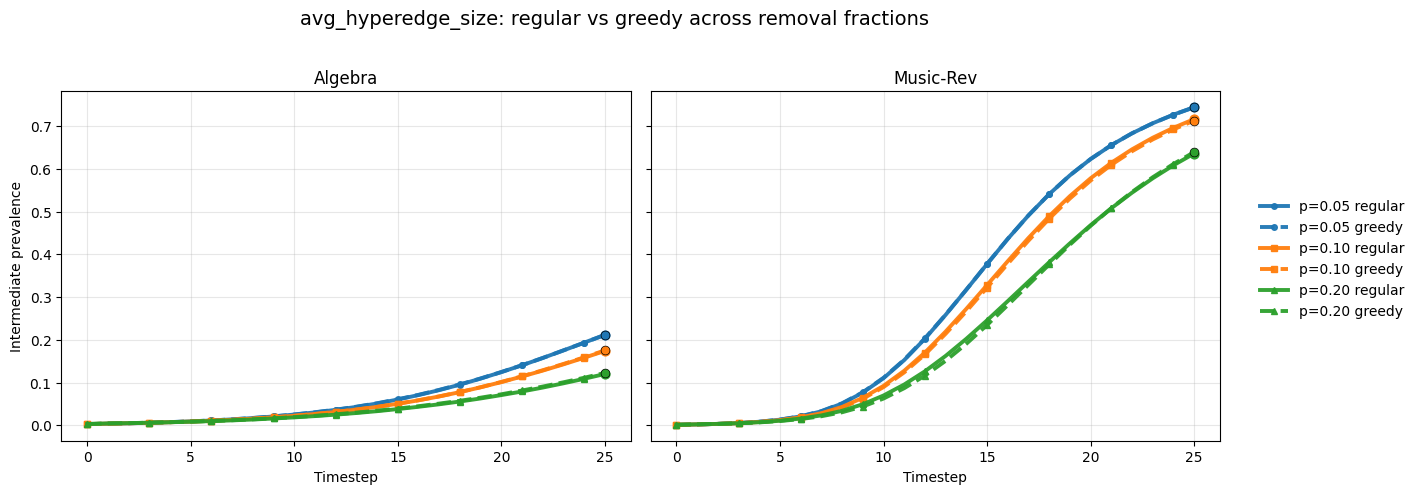

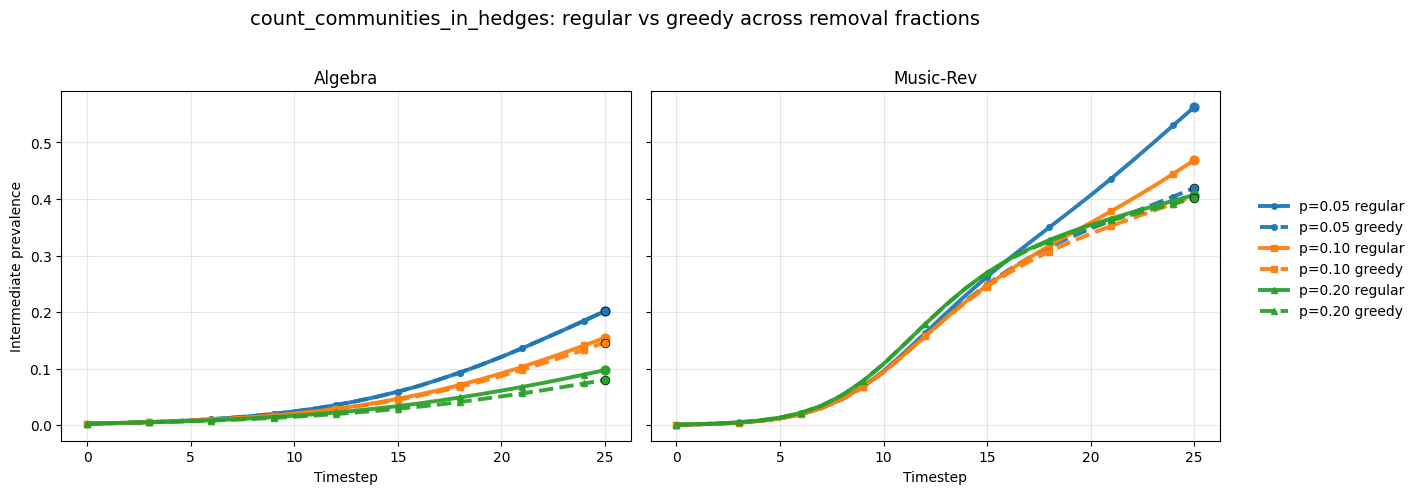

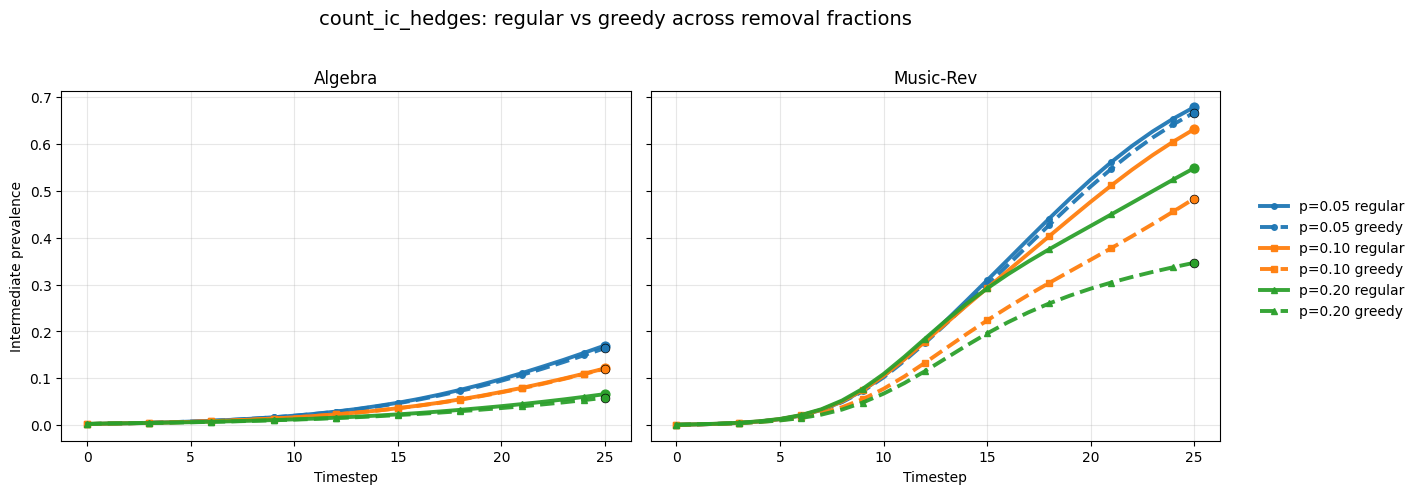

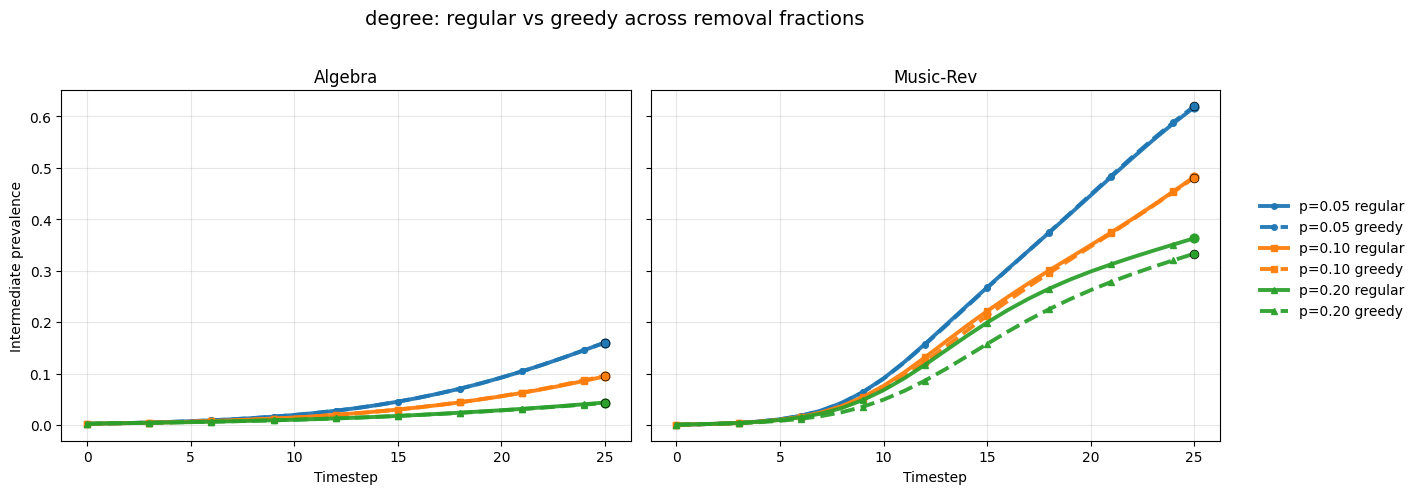

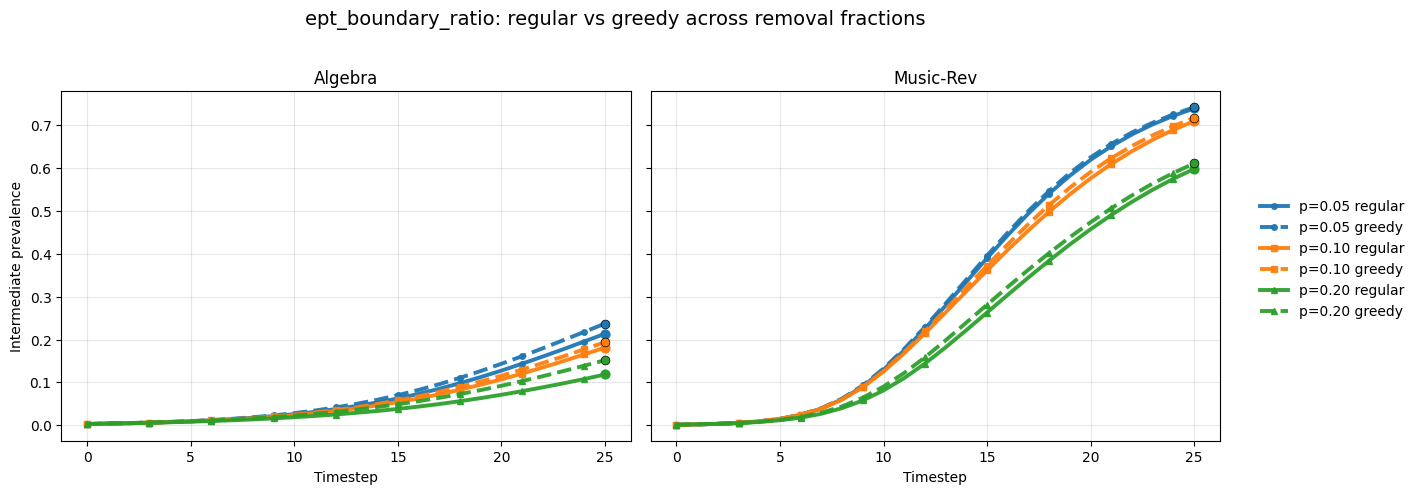

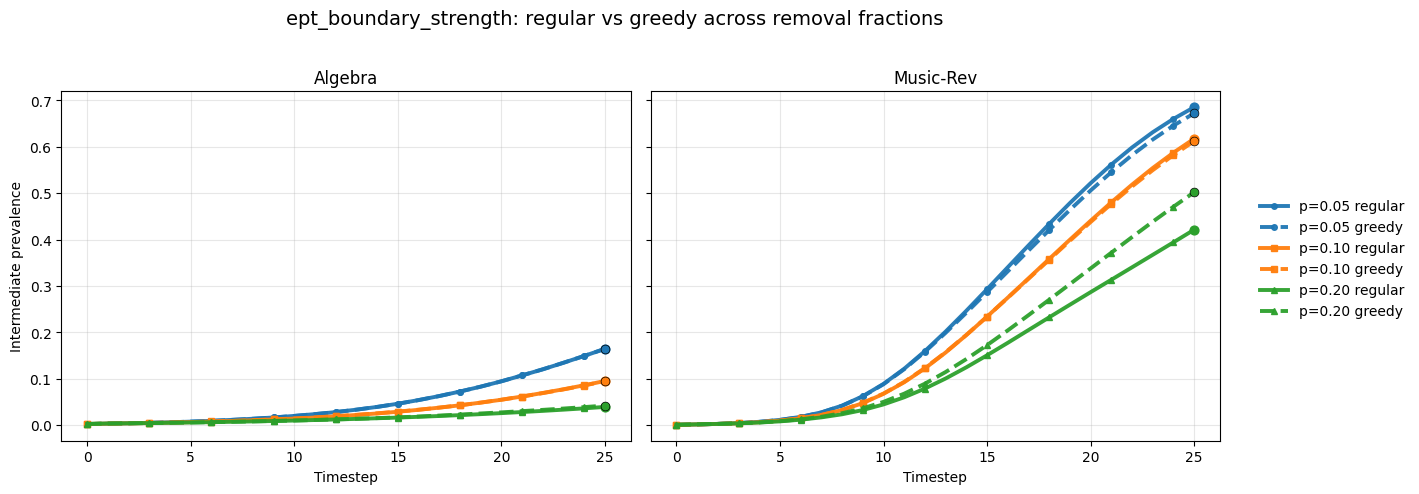

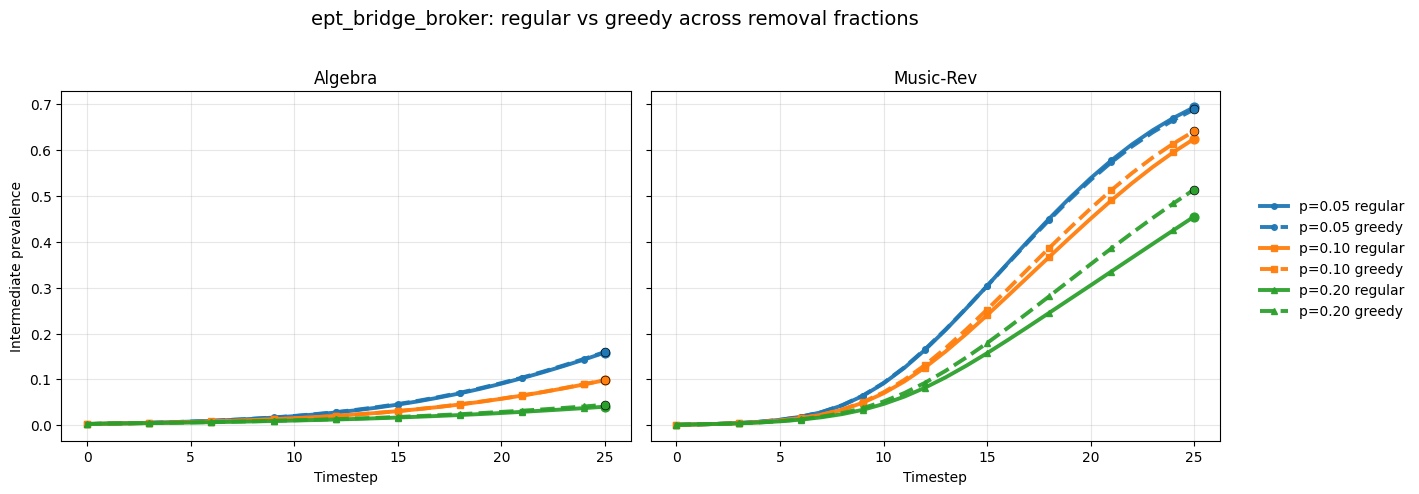

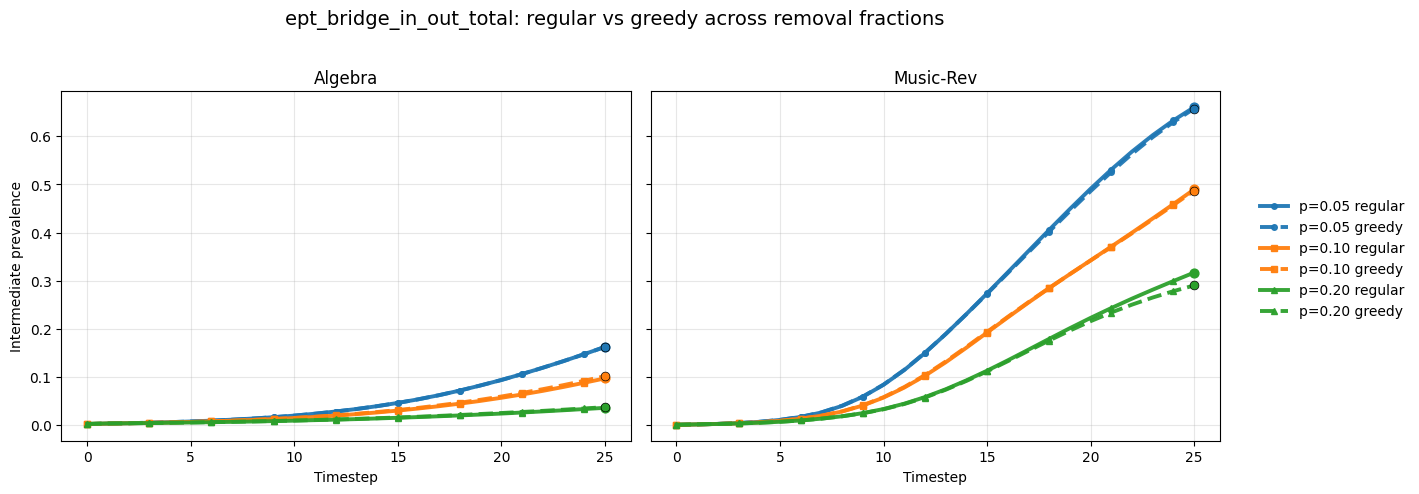

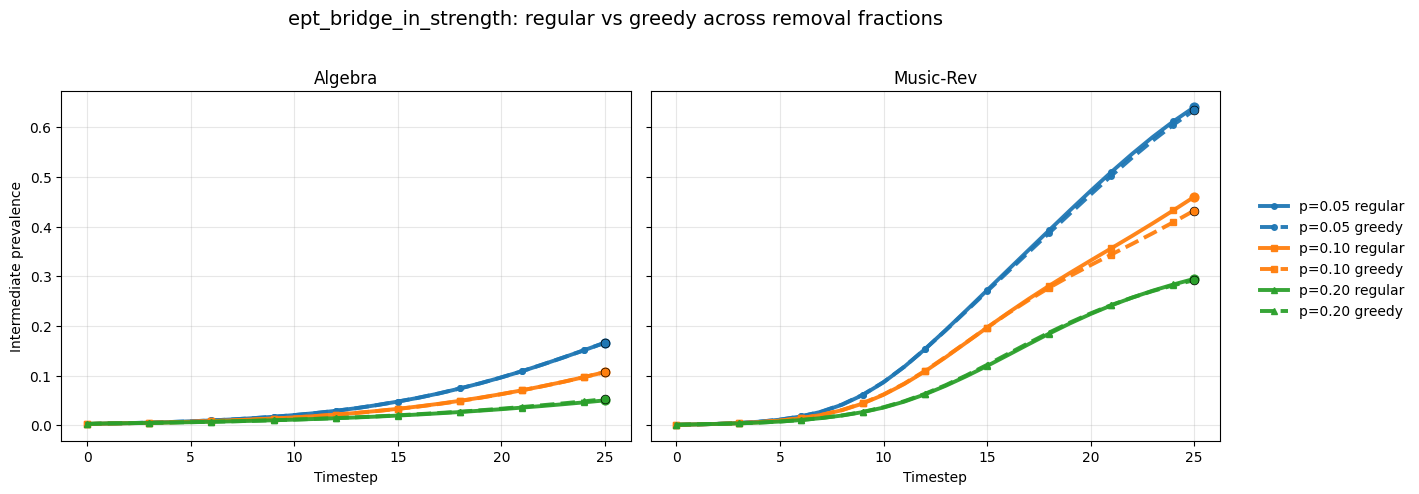

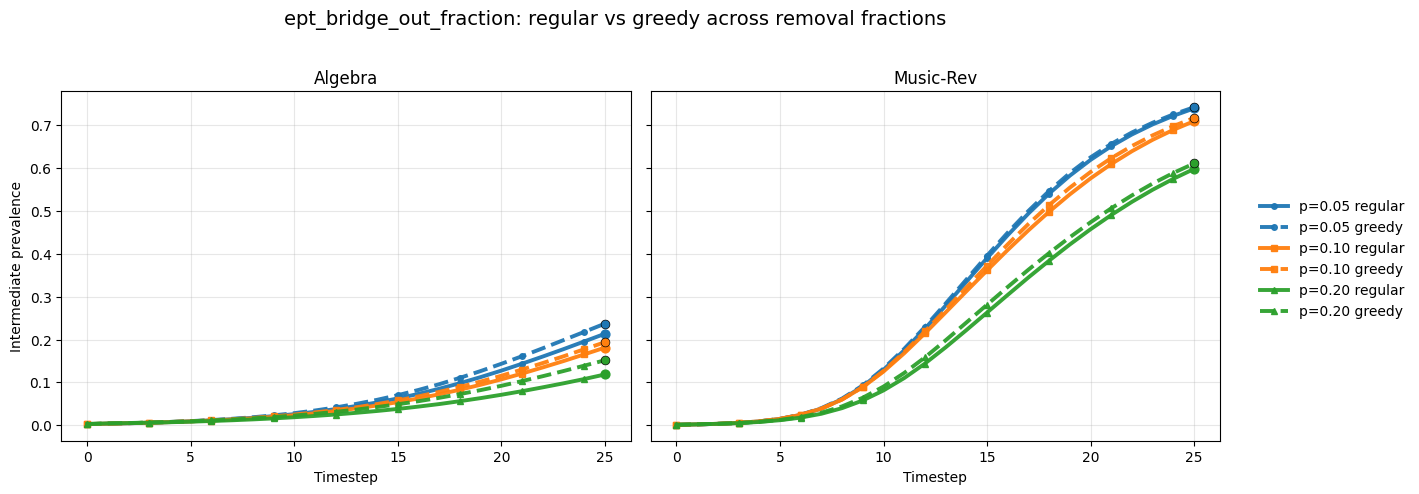

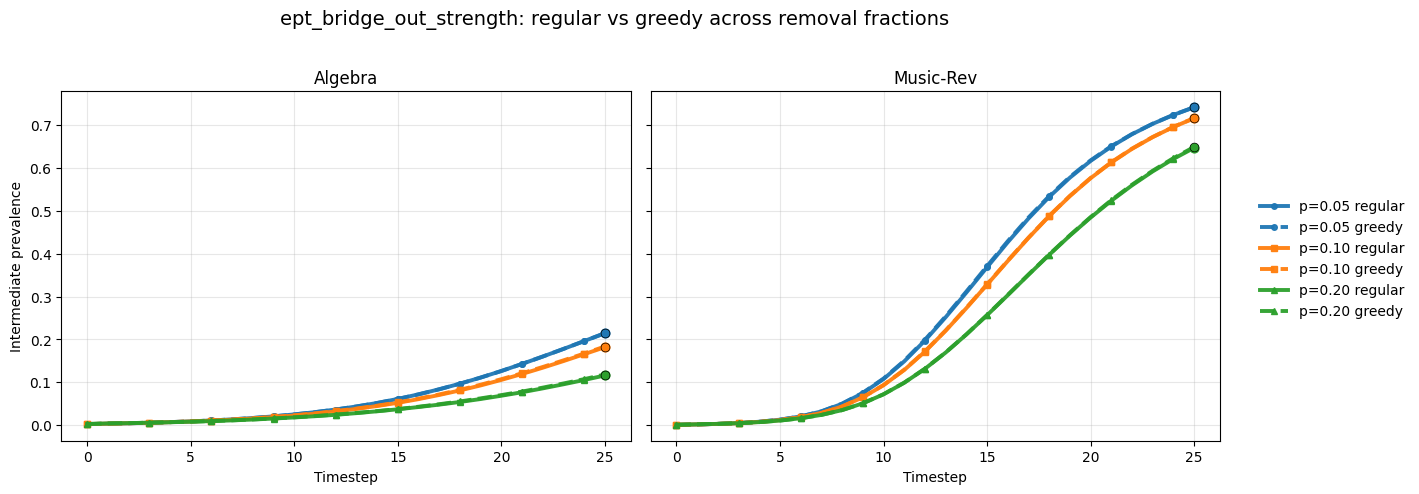

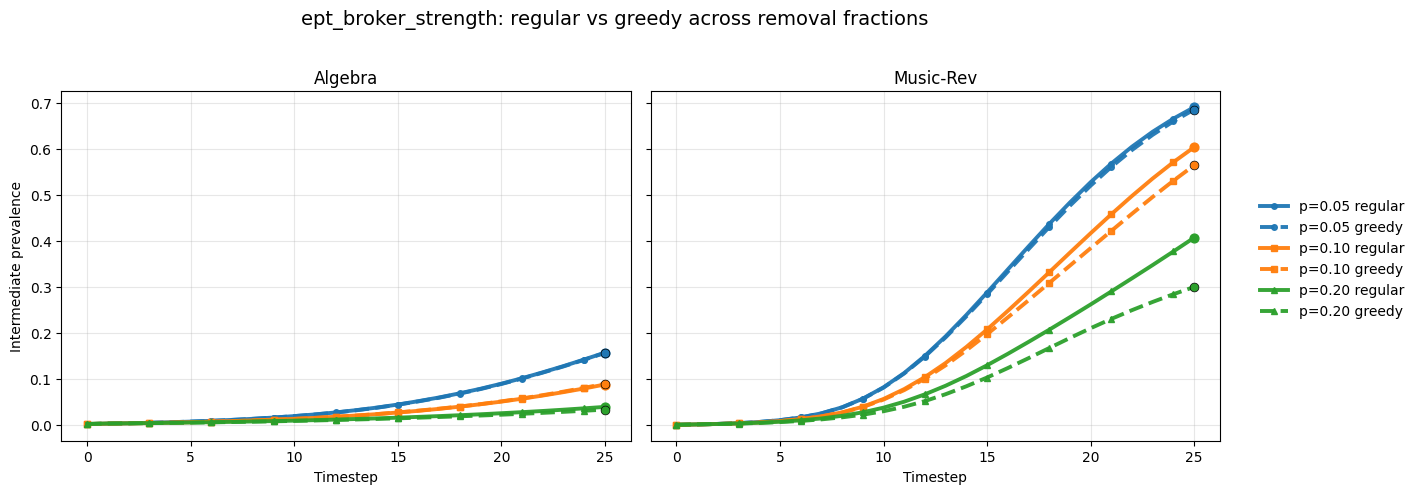

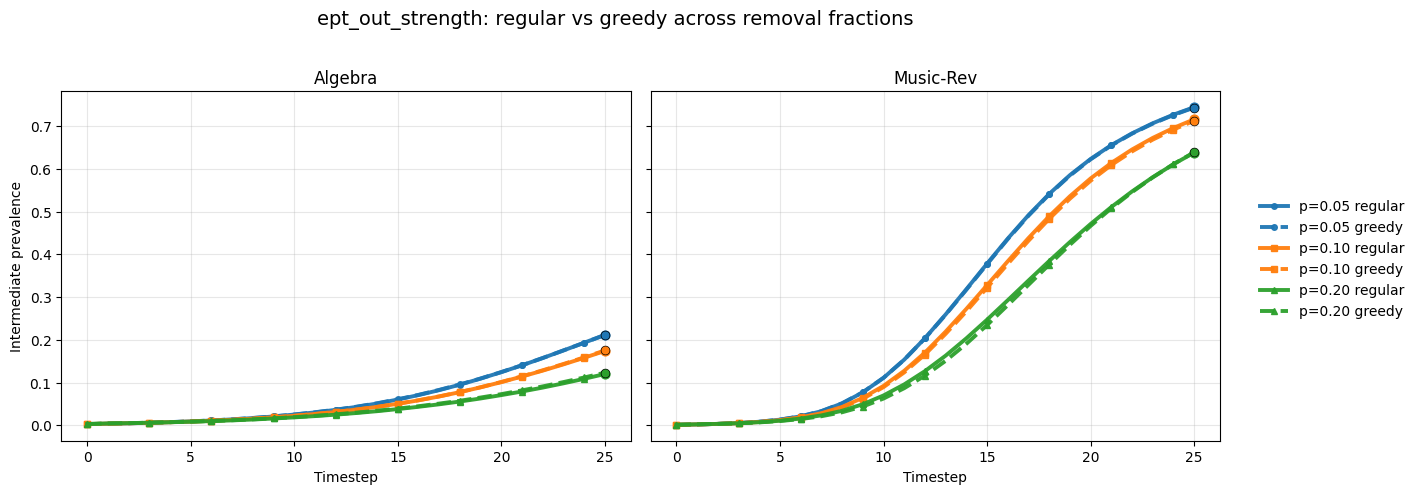

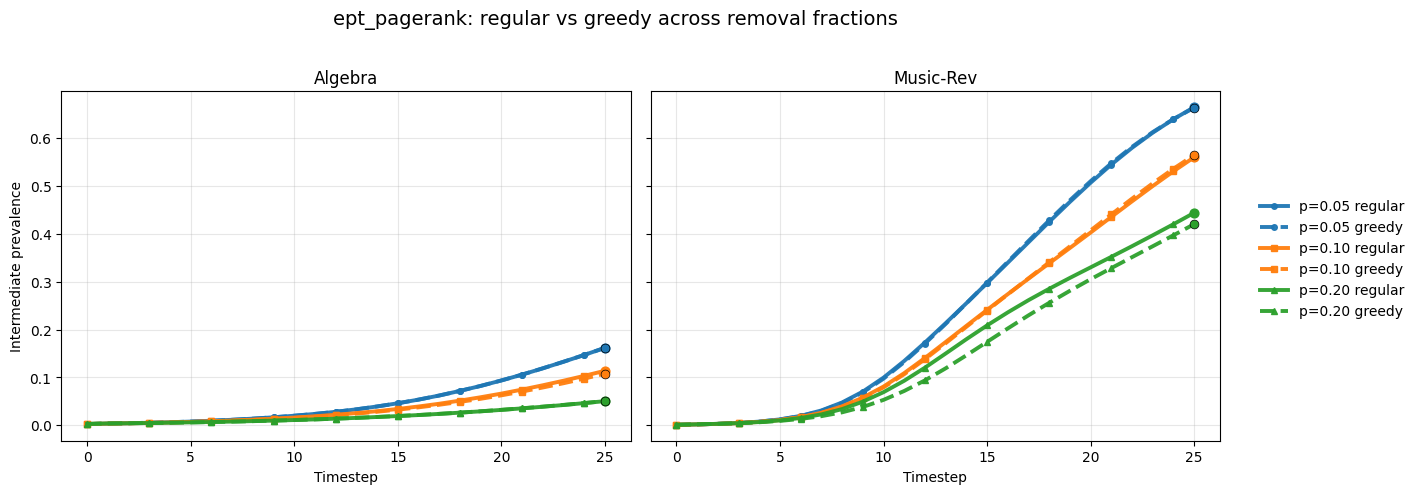

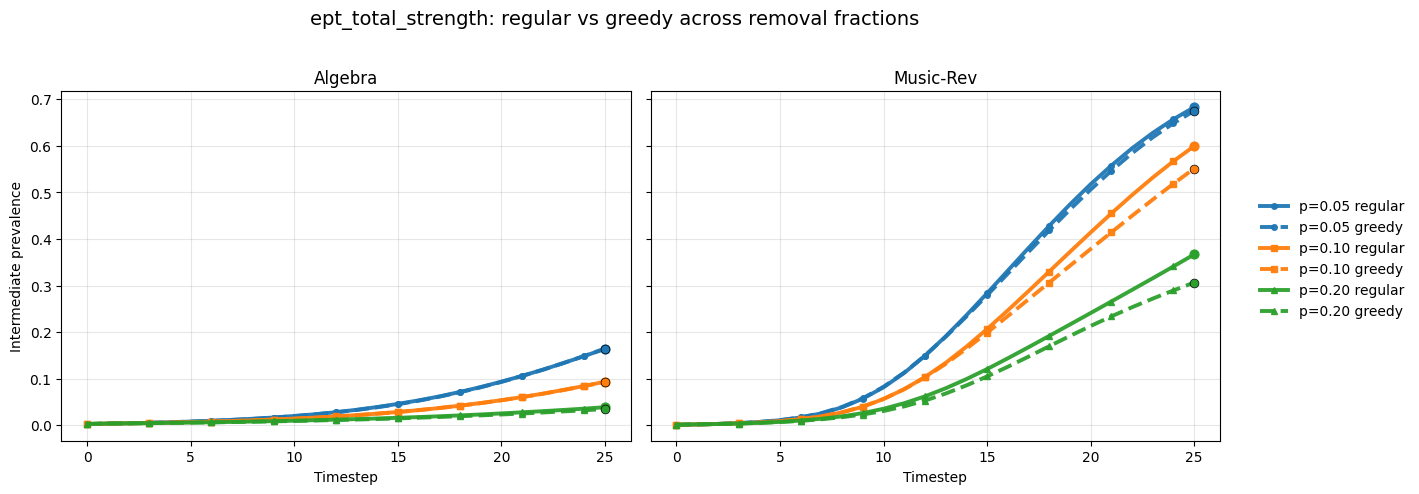

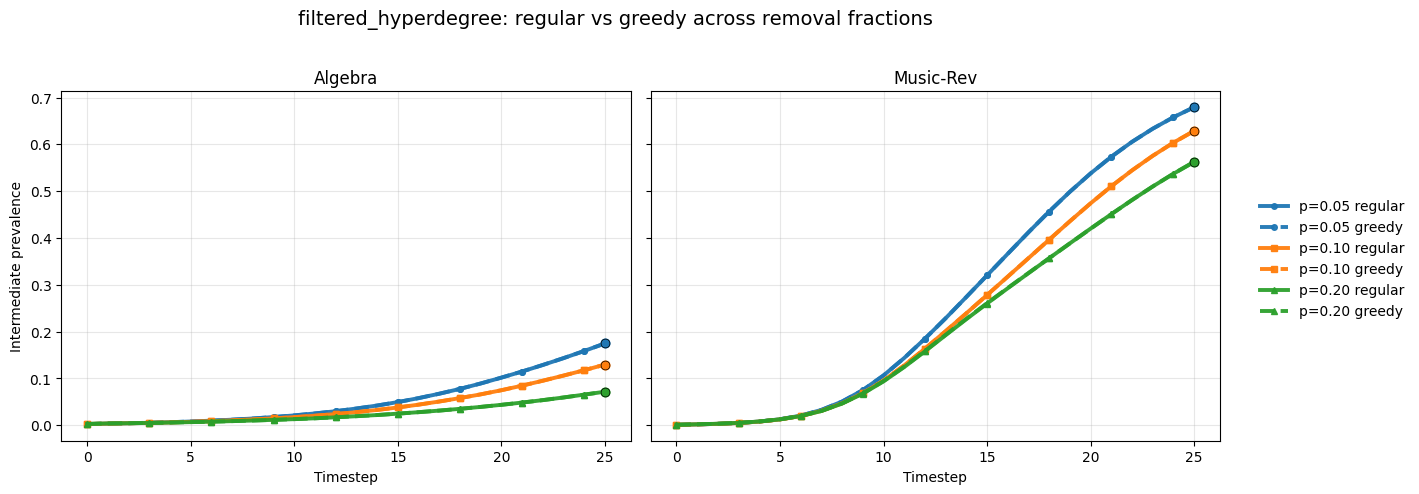

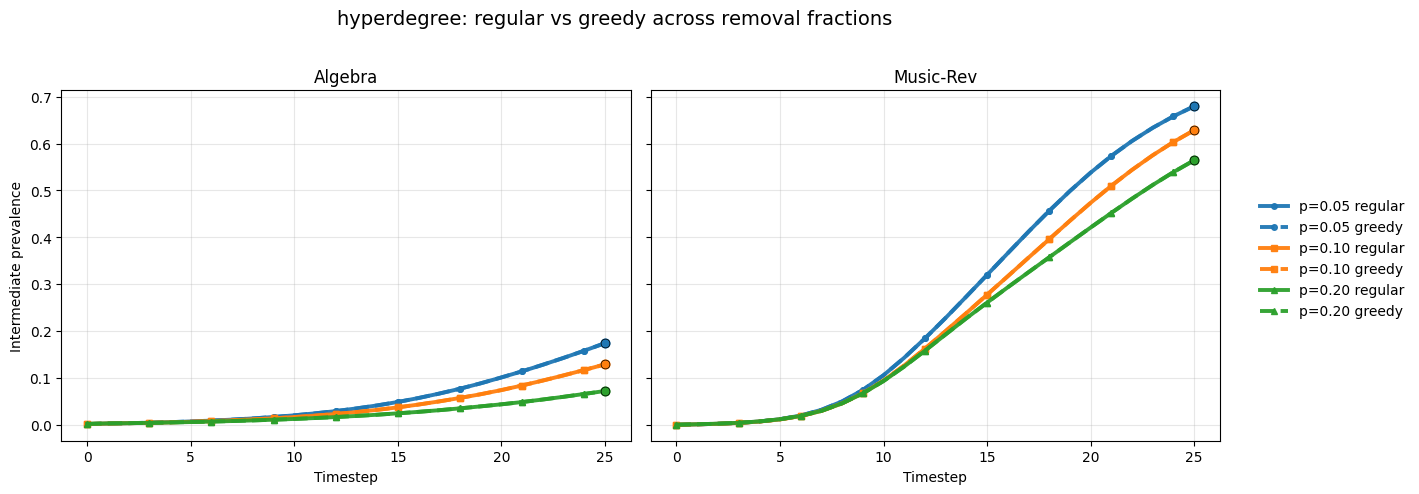

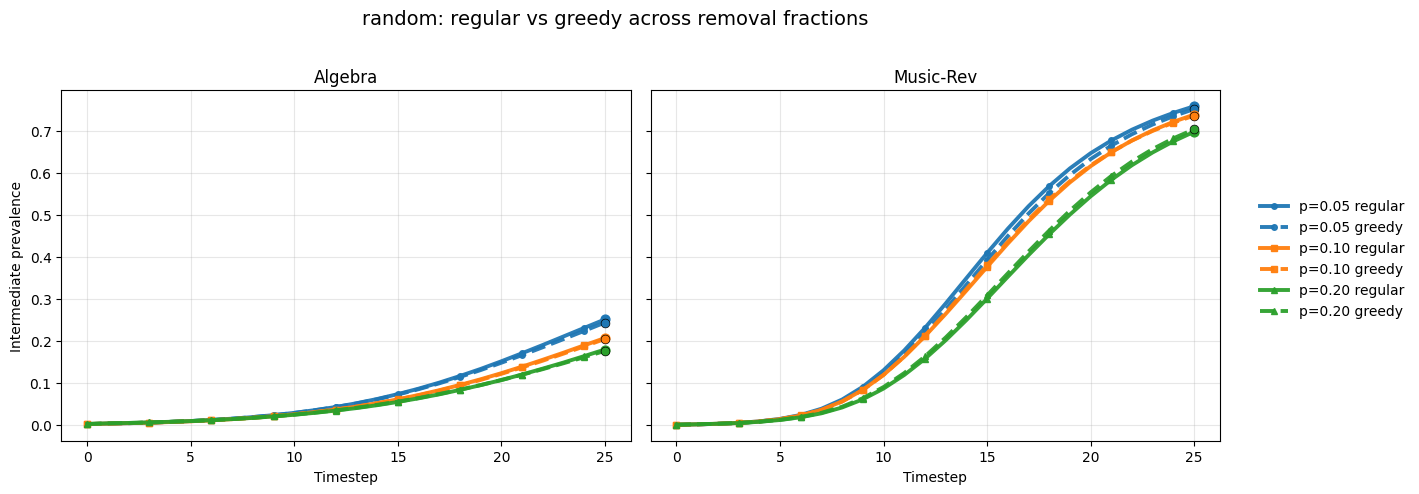

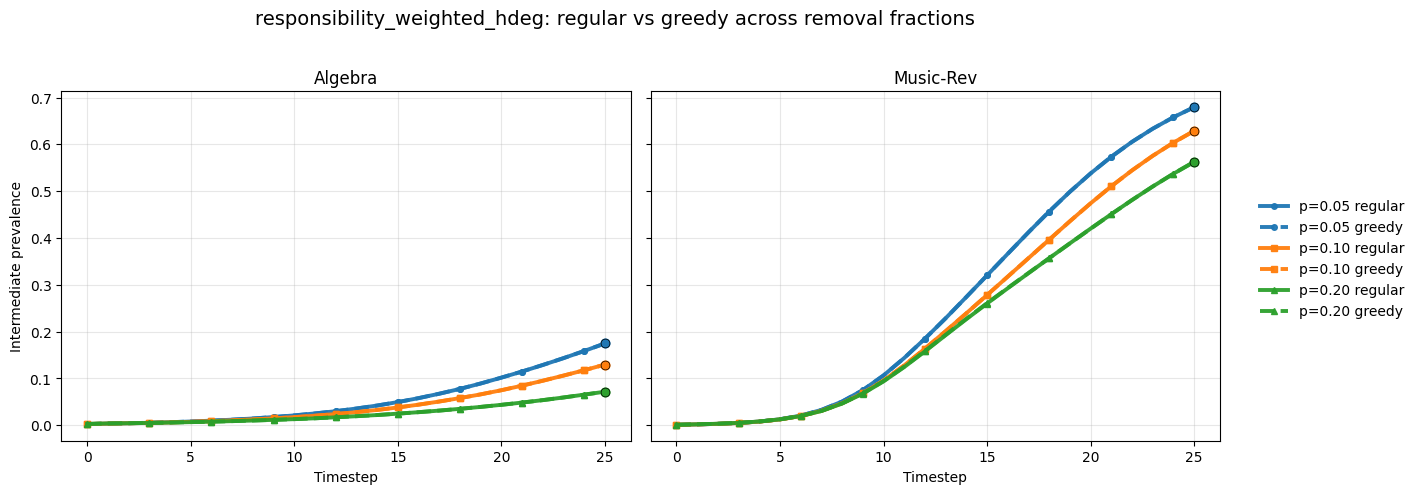

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Load all result CSVs
# ============================================================
result_dir = Path("../outputs/sim-results-all-strats-greedy")
files = sorted(result_dir.glob("*_comprehensive_results.csv"))

if not files:
    raise FileNotFoundError("No comprehensive result CSVs found.")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# ============================================================
# Prepare columns
# ============================================================
df["p"] = df["p"].astype(float)
df["timestep"] = df["timestep"].astype(int)
df["mean_infected"] = df["mean_infected"].astype(float)
df["remaining_nodes"] = df["remaining_nodes"].astype(float)

# Prevalence = infected fraction
df["prevalence"] = np.where(
    df["remaining_nodes"] > 0,
    df["mean_infected"] / df["remaining_nodes"],
    0.0
)

datasets = sorted(df["dataset"].unique())
p_values = sorted(df["p"].unique())

# Only strategies that have a greedy counterpart
all_strats = sorted(df["strategy"].unique())
base_strats = sorted([
    s for s in all_strats
    if not s.endswith("_greedy") and f"{s}_greedy" in all_strats
])

if not base_strats:
    raise ValueError("No regular/greedy strategy pairs found.")

# ============================================================
# Styling: same color per p, linestyle separates regular vs greedy
# ============================================================
color_map = {
    p: c for p, c in zip(
        p_values,
        ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
    )
}
marker_map = {
    p: m for p, m in zip(
        p_values,
        ["o", "s", "^", "D", "v", "P"]
    )
}

# ============================================================
# Make one figure per strategy
# ============================================================
for base in base_strats:
    ncols = len(datasets)
    fig, axes = plt.subplots(
        1, ncols,
        figsize=(6.2 * ncols, 4.8),
        sharey=True
    )

    if ncols == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        sub = df[df["dataset"] == dataset]

        for p in p_values:
            c = color_map[p]
            m = marker_map[p]

            reg = sub[
                (sub["strategy"] == base) &
                (sub["p"] == p)
            ].sort_values("timestep")

            gry = sub[
                (sub["strategy"] == f"{base}_greedy") &
                (sub["p"] == p)
            ].sort_values("timestep")

            if not reg.empty:
                ax.plot(
                    reg["timestep"],
                    reg["prevalence"],
                    color=c,
                    linestyle="-",
                    linewidth=2.8,
                    marker=m,
                    markersize=4,
                    markevery=max(1, len(reg) // 8),
                    alpha=0.95,
                    label=f"p={p:.2f} regular"
                )
                # emphasize final point
                ax.scatter(
                    reg["timestep"].iloc[-1],
                    reg["prevalence"].iloc[-1],
                    color=c,
                    s=40,
                    zorder=5
                )

            if not gry.empty:
                ax.plot(
                    gry["timestep"],
                    gry["prevalence"],
                    color=c,
                    linestyle="--",
                    linewidth=2.8,
                    marker=m,
                    markersize=4,
                    markevery=max(1, len(gry) // 8),
                    alpha=0.95,
                    label=f"p={p:.2f} greedy"
                )
                # emphasize final point
                ax.scatter(
                    gry["timestep"].iloc[-1],
                    gry["prevalence"].iloc[-1],
                    color=c,
                    s=40,
                    zorder=5,
                    edgecolor="black",
                    linewidth=0.5
                )

        ax.set_title(f"{dataset}")
        ax.set_xlabel("Timestep")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Intermediate prevalence")

    # Build one shared legend without duplicates
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)

    fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )

    fig.suptitle(
        f"{base}: regular vs greedy across removal fractions",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()
    plt.show()